## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import pickle
import os
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision.models import convnext_base, ConvNeXt_Base_Weights, resnet18, ResNet18_Weights
import matplotlib.pyplot as plt

from deepfake_utils.datasets import DeepFakeDataset
from deepfake_utils.train import train_epoch, validate_epoch
from torch.utils.tensorboard import SummaryWriter

from torcheval.metrics.functional import binary_auroc, binary_auprc

In [10]:
image_dir_path = 'Deepfake-Eval-2024/image-data'
model_type = 'ConvNeXt'

# small subset of training data to run on CPU and debug functional issues
debug_data = DeepFakeDataset("image-metadata-debug.csv", image_dir_path, model_type, is_train = True)
debug_data_loader = DataLoader(debug_data, batch_size = 32, shuffle = False)

# model = convnext_base(weights = ConvNeXt_Base_Weights.DEFAULT)
model = resnet18(weights = ResNet18_Weights.DEFAULT)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.64].


torch.Size([32, 1000])


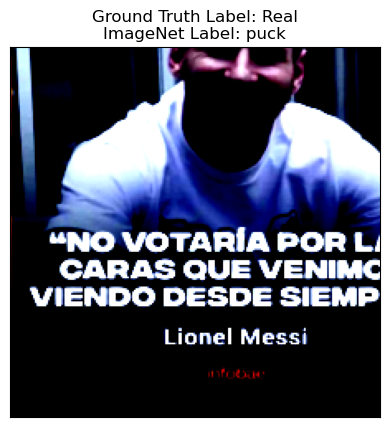

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.64].


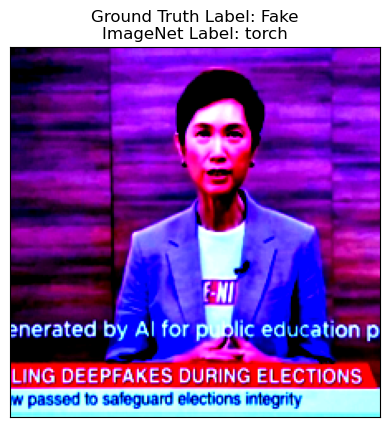

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.64].


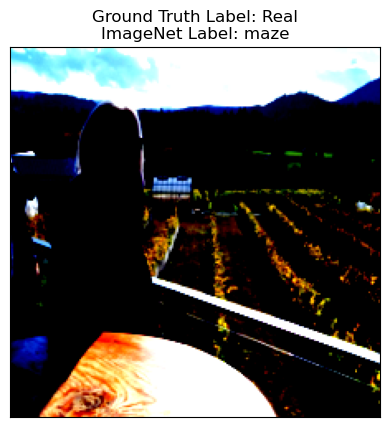

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].


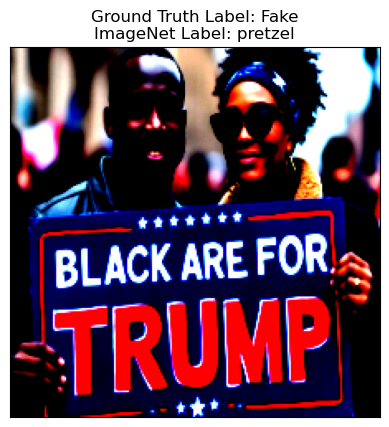

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.64].


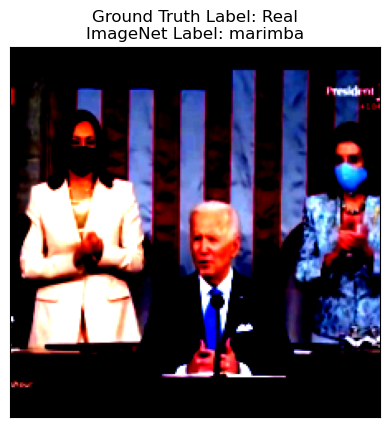

In [11]:
count = 0
features, label = next(iter(debug_data_loader))
with torch.no_grad():
    model_output = model(features)
    print(model_output.shape)

for i in range(5):

    img = features[i]
    # print(predictions[0].argmax(-1).item())
    imagenet_label = ResNet18_Weights.DEFAULT.meta['categories'][model_output[i].argmax(-1).item()]

    plt.imshow(np.transpose(img, (1,2,0))) # convert pytorch tensor (3 channels, H, W) to numpy array (H, W, 3 channels)
    plt.title(f"Ground Truth Label: {'Fake' if label[i] else 'Real'}\nImageNet Label: {imagenet_label}")
    plt.xticks([])
    plt.yticks([])
    plt.show()

In [12]:
# # modify ConvNeXtclassifier head for deepfake detection
# classifier_head_layers = [layer for layer in model.classifier]
# classifier_head_layers[2] = nn.Linear(in_features=1024, out_features=2, bias = True)
# model.classifier = nn.Sequential(*classifier_head_layers)

In [13]:
# modify ResNet classifier head for deepfake detection
model.fc = nn.Linear(in_features = 512, out_features=2, bias = True)

# # freeze all model parameters
# for param in model.parameters():
#     param.requires_grad = False

# # unfreeze parameters (i.e. coefficients) in classifier head
# for param in model.fc.parameters():
#     param.requires_grad = True

In [14]:
# torch.cuda.get_device_name(0)

In [15]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)
learning_rate = 1e-3
batch_size = 32
epochs = 3
loss_fn = nn.CrossEntropyLoss(reduction = 'sum')
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)
# optimizer = torch.optim.LBFGS(model.parameters(), max_iter = 5, history_size = 10)

In [16]:
train_data = DeepFakeDataset("image-metadata-train.csv", image_dir_path, model_type, is_train = True)
train_data_loader = DataLoader(train_data, batch_size = batch_size, shuffle = True)

val_data = DeepFakeDataset("image-metadata-val.csv", image_dir_path, model_type, is_train = False)
val_data_loader = DataLoader(val_data, batch_size = batch_size, shuffle = False)


In [17]:
# writer = SummaryWriter()
train_loss_, train_auroc_, train_auprc_, val_loss_, val_auroc_, val_auprc_ = [None] * epochs, [None] * epochs, [None] * epochs, [None] * epochs, [None] * epochs, [None] * epochs
for t in range(epochs):
    print(f"Epoch {t+1}\n- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - ")
    print("Training...")
    train_loss, train_auroc, train_auprc, train_acc = train_epoch(debug_data_loader, model, loss_fn, optimizer, device)
    print("Validating...")
    val_loss, val_auroc, val_auprc, val_acc = validate_epoch(debug_data_loader, model, loss_fn, device)
#     writer.add_scalar('training loss', train_loss, t)
#     writer.add_scalar('validation loss', val_loss, t)
#     writer.add_scalar('training roc auc', train_auroc, t)
#     writer.add_scalar('validation roc auc', val_auroc, t)
#     writer.add_scalar('training pr auc', train_auprc, t)
#     writer.add_scalar('validation pr auc', val_auprc, t)
    print(f"Training Error: \n\tLoss: {train_loss:>8f}\tROC AUC: {train_auroc:>4f}\tPR AUC: {train_auprc:>4f}\tAccuracy: {train_acc:>4f}")
    print(f"Validation Error: \n\tLoss: {val_loss:>8f}\tROC AUC: {val_auroc:>4f}\tPR AUC: {val_auprc:>4f}\tAccuracy: {val_acc:>4f}")
    train_loss_[t], train_auroc_[t], train_auprc_[t], val_loss_[t], val_auroc_[t], val_auprc_[t] = train_loss, train_auroc, train_auprc, val_loss, val_auroc, val_auprc
    # writer.close()
print("Done!")

Epoch 1
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
Training...
Training Progress: 	[   32/  200]
Training Progress: 	[   64/  200]
Training Progress: 	[   96/  200]
Training Progress: 	[  128/  200]
Training Progress: 	[  160/  200]
Training Progress: 	[  192/  200]
Training Progress: 	[  200/  200]
Evaluation Progress: 	[   32/  200]
Evaluation Progress: 	[   64/  200]
Evaluation Progress: 	[   96/  200]
Evaluation Progress: 	[  128/  200]
Evaluation Progress: 	[  160/  200]
Evaluation Progress: 	[  192/  200]
Evaluation Progress: 	[  200/  200]
Validating...
Evaluation Progress: 	[   32/  200]
Evaluation Progress: 	[   64/  200]
Evaluation Progress: 	[   96/  200]
Evaluation Progress: 	[  128/  200]
Evaluation Progress: 	[  160/  200]
Evaluation Progress: 	[  192/  200]
Evaluation Progress: 	[  200/  200]
Training Error: 
	Loss: 1.283413	ROC AUC: 0.705675	PR AUC: 0.770177	Accuracy: 0.660000
Validation Error: 
	Loss: 1.196749	ROC AUC: 0.717398	PR AUC: 0.803531	Accura

In [ ]:
with open(f"train_progress.pkl", "wb") as f:
    pickle.dump((train_loss_, train_auroc_, train_auprc_, val_loss_, val_auroc_, val_auprc_), f)
    f.close()

In [ ]:
with open("train_progress.pkl", "rb") as f:
    train_loss_, train_auroc_, train_auprc_, val_loss_, val_auroc_, val_auprc_ = pickle.load(f)

In [ ]:
# plt.rcParams['font.family'] = 'serif'
# plt.rcParams['font.serif'] = ['Times New Roman']
# plt.rcParams['font.size'] = 10
# plt.rcParams["axes.formatter.use_mathtext"] = True
# plt.rcParams["text.usetex"] = True

In [ ]:
train_auroc_

In [ ]:
plt.title("ConvNeXt Learning Curve")
plt.plot(train_auroc_, label = 'Training ROC AUC')
plt.plot(val_auroc_, label = 'Validation ROC AUC')
plt.xlabel("Epoch")
plt.grid(axis = 'both')
plt.xticks([0,1,2])
plt.legend()
plt.show()